![alt text](<Pratech beyaz yazı logosu.png>)

In [ ]:
#Merhabalar Sayın Aday, Pratech stajyer alım sürecimizin teknik değerlendirme aşamasına hoş geldin.
# Senden isteğimiz aşağıdaki görevlerden birini seçmen ve bunu bizlere bu adresten teslim etmen:
# https://forms.gle/VbWCpUcmxakJmGLg7

# Sectigim Görev:

#5. Görüntü İşleme (Computer Vision) ile Ürün Kategoril endirme

#Seçtiğiniz 1 görev üzerinde çalışarak,yapay zeka ve veri bilimi alanındaki yetkinliklerinizi göstermek için bu fırsatı
#en iyi şekilde değerlendirin.Her bir görevin amacı, gerçek dünya problemlerine yönelik çözümler üretme becerilerinizi ortaya koymaktır.
#Başarılar dileriz!


Merhabalar Sayın Aday, Pratech stajyer alım sürecimizin teknik değerlendirme aşamasına hoş geldin. Senden isteğimiz aşağıdaki görevlerden birini seçmen ve bunu bizlere bu adresten teslim etmen:   https://forms.gle/VbWCpUcmxakJmGLg7

# Turce Biliyorum ama inglizcede daha iyi anlatabilirim diye dusunarak, inglizcede devam ettim.

Görev 5: Görüntü İşleme ve OCR (Optik Karakter Tanıma) ile Fiş Okuma
Senaryo: Kağıt fişlerin dijitalleşmesi vizyonumuz doğrultusunda, fiziksel bir fiş görüntüsünden anlamlı veriler çıkarmanı bekliyoruz.
Beklenti: Linkte bulunan örnek market fişi fotoğraflarını (https://drive.google.com/drive/folders/1gXwjDypMomPpwp0h_dHR0-x_qjE8mwuM?usp=sharing ) .ipynb dosyasına yükle. Python kullanarak (OpenCV, Tesseract, EasyOCR vb.) bu görseldeki metinleri çıkar ve "Tarih, Toplam Tutar, KDV" gibi alanları ayıklayarak yapılandırılmış bir formata (Dictionary veya Pandas DataFrame) dönüştür.
Değerlendirme Kriterleri (100 Puan):

Görüntü Ön İşleme (30 Puan): OCR başarısını artırmak için görüntünün OpenCV ile (siyah-beyaz yapma, gürültü temizleme vb.) işlenmesi.

Metin Çıkarımı (30 Puan): Seçilen OCR kütüphanesinin doğru ve verimli kullanılması.

Veri Ayıklama (Regex) (20 Puan): Çıkan saf metnin içinden Düzenli İfadeler (Regex) ile istenen alanların bulunması.

Sonuç Yapılandırma (20 Puan): Elde edilen verilerin Notebook'un en sonunda tablo veya JSON formatında temiz bir şekilde ekrana yazdırılması.

In [ ]:
#Görev 5: Görüntü İşleme ve OCR (Optik Karakter Tanıma) ile Fiş Okuma


# Receipt Reader

In [1]:
!pip install opencv-python easyocr pytesseract pandas Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 17.9 MB/s eta 0:00:00


In [2]:
!sudo apt install tesseract-ocr tesseract-ocr-tur -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-tur
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 1,578 kB of archives.
After this operation, 4,565 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-tur all 1:4.00~git30-7274cfa-1.1 [1,578 kB]
Fetched 1,578 kB in 1s (1,501 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Sele

In [3]:
import cv2
import numpy as np
from PIL import Image

import easyocr
import pytesseract

import re
import json
import pandas as pd

import os, glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


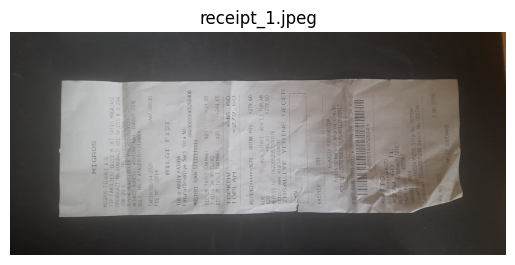



Loaded: receipt_1.jpeg | Shape: (900, 2000, 3)




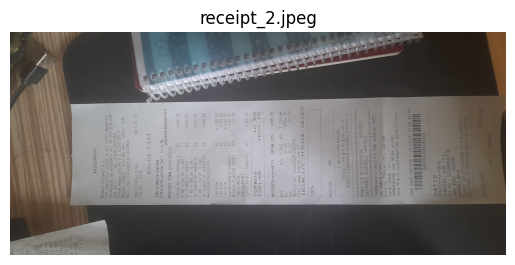



Loaded: receipt_2.jpeg | Shape: (900, 2000, 3)




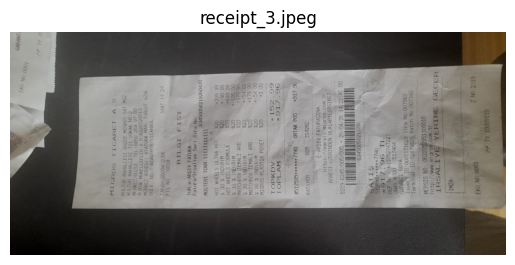



Loaded: receipt_3.jpeg | Shape: (900, 2000, 3)




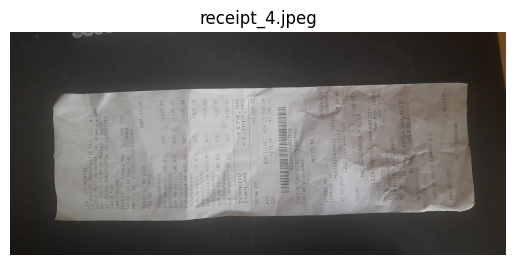



Loaded: receipt_4.jpeg | Shape: (900, 2000, 3)




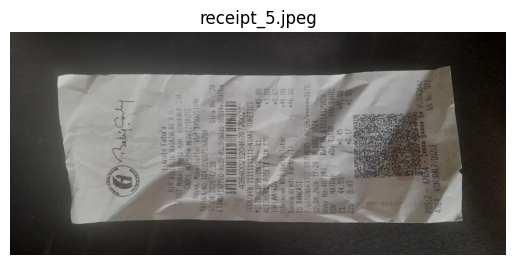



Loaded: receipt_5.jpeg | Shape: (900, 2000, 3)




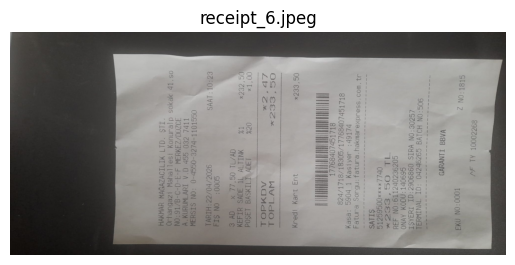



Loaded: receipt_6.jpeg | Shape: (900, 2000, 3)




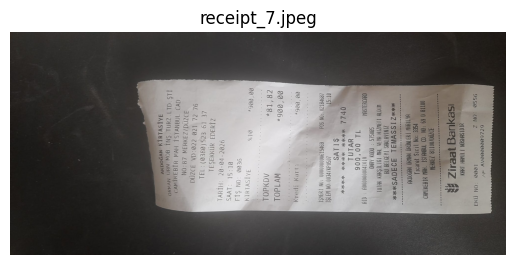



Loaded: receipt_7.jpeg | Shape: (900, 2000, 3)




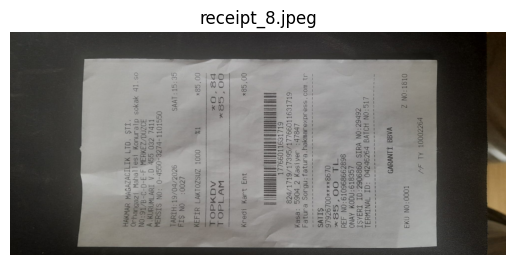



Loaded: receipt_8.jpeg | Shape: (900, 2000, 3)




In [9]:
FOLDER_PATH = '/content/drive/MyDrive/receipts'

for image_name in os.listdir(FOLDER_PATH):
  image_path = os.path.join(FOLDER_PATH, image_name)
  img = cv2.imread(image_path)

  if img is None:
    print(f"Warning: Could not load image {image_name}. Skipping.")
    continue

  img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.imshow(img_display)
  plt.title(os.path.basename(image_name))
  plt.axis('off')
  plt.show()

  print('\n')
  print(f"Loaded: {image_name} | Shape: {img.shape}")
  print('\n')

In [51]:
def preprocess(img):

  img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  h, w = gray.shape
  if w > 1000:
    scale = 1000 / w
    gray = cv2.resize(gray, (1000, int(h * scale)))

  denoised = cv2.fastNlMeansDenoising(gray, h=15)

  # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  # enhanced = clahe.apply(denoised)

  # _, thresh = cv2.threshold(
  #     enhanced, 0, 255,
  #     cv2.THRESH_BINARY + cv2.THRESH_OTSU
  #     )

  thresh = cv2.adaptiveThreshold(
      denoised, 255,
      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
      cv2.THRESH_BINARY, 11, 2
      )

  return thresh

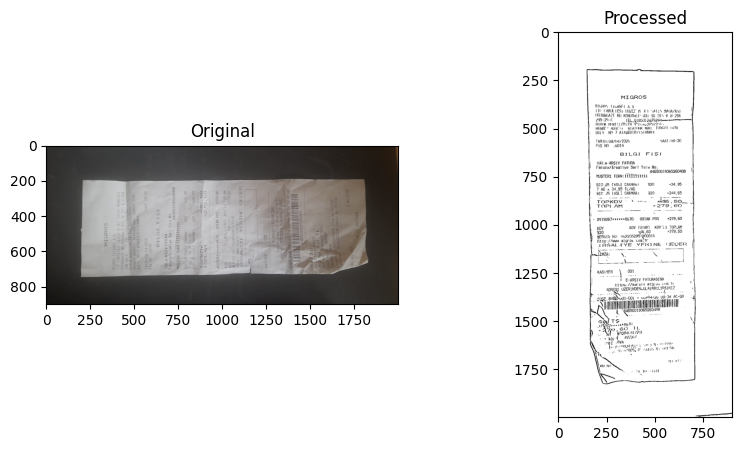

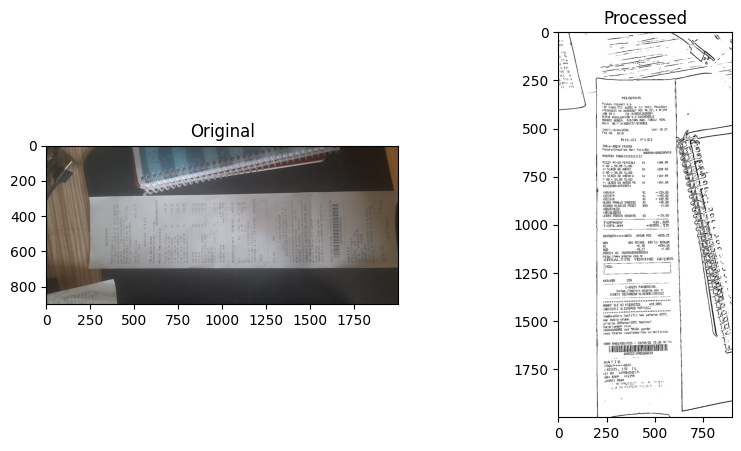

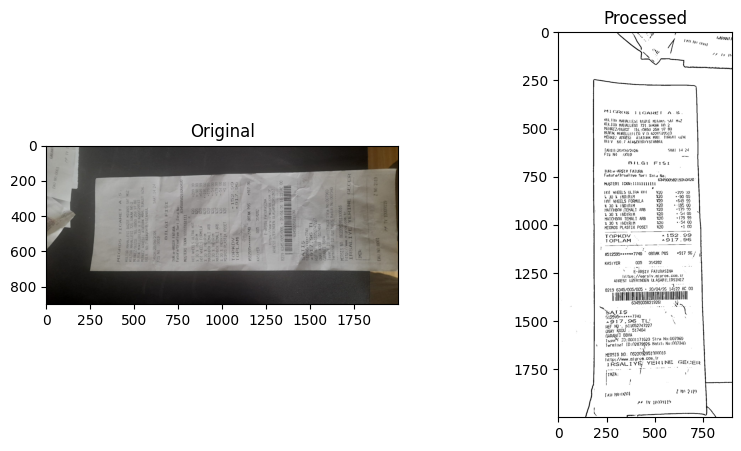

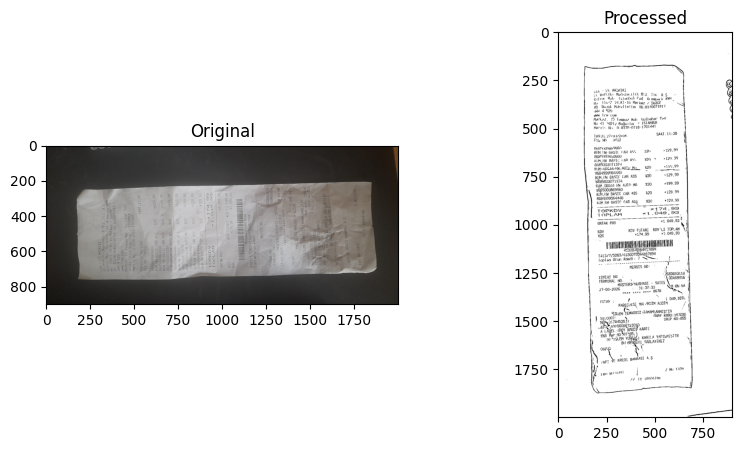

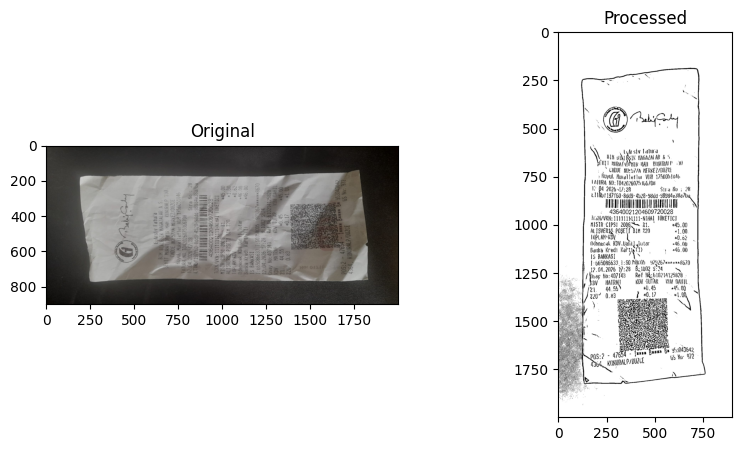

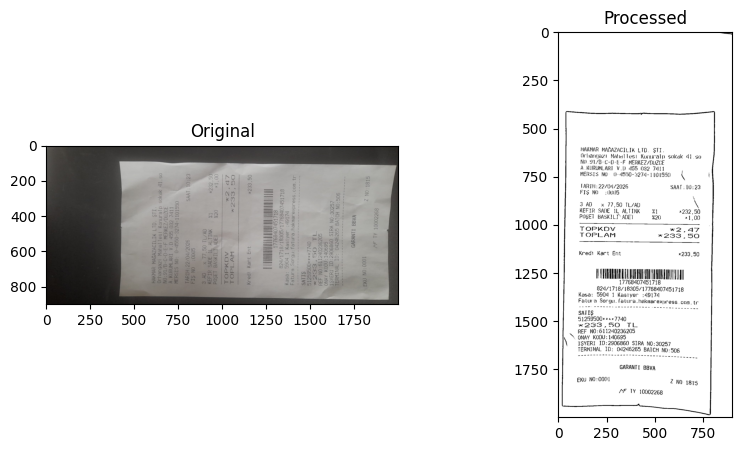

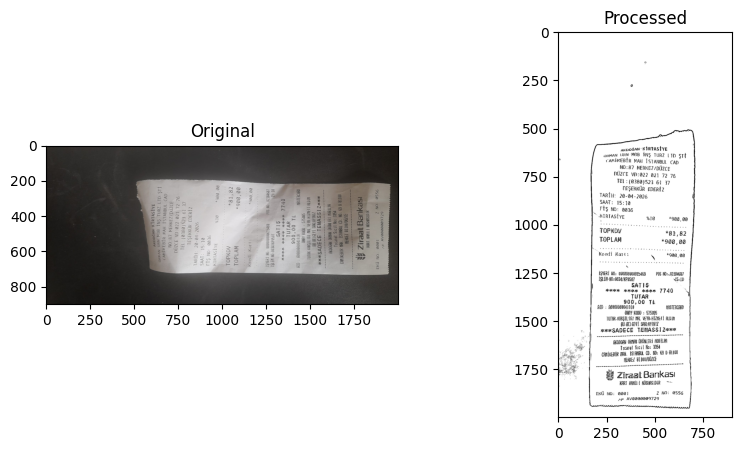

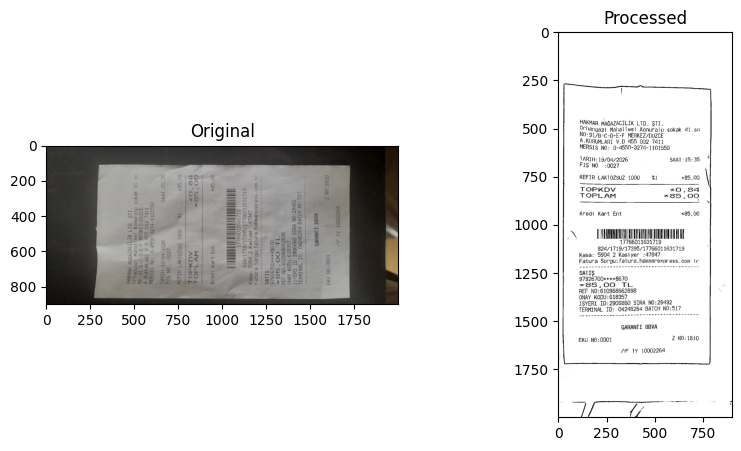

In [43]:
for path in os.listdir(FOLDER_PATH):

  image_path = os.path.join(FOLDER_PATH, path)
  img = cv2.imread(image_path)
  processed = preprocess(img)

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  axes[0].set_title("Original")
  axes[1].imshow(processed, cmap='gray')
  axes[1].set_title("Processed")
  plt.show()

In [16]:
reader = easyocr.Reader(['tr', 'en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [17]:
def extract_text(processed_img):

  results = reader.readtext(processed_img)
  easy_text = "\n".join([text for (_, text, conf) in results if conf > 0.3])

  tess_text = pytesseract.image_to_string(
      processed_img,
      lang='tur',
      config='--psm 6'
      )

  final_text = easy_text if len(easy_text) > len(tess_text) else tess_text

  return final_text, easy_text, tess_text

In [44]:
image = '/content/drive/MyDrive/receipts/receipt_8.jpeg'
img = cv2.imread(image)
processed = preprocess(img)
final_text, easy_text, tess_text = extract_text(processed)
print(final_text)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


! ”
HAKMAR MAĞAZACILIK LTD. ŞTI.
Orhangazi Mahallesi Konuralp sokak 41.s0
NO:91/B-0-D-E-F MERKEZ/DUZCE
A.KURUMLARI V.D AS5 032 7411
MERS1S NO: 0-4550-3274-1101550
TARIH: 19/04/2026 SAAT:15:35. *
FIŞNO :0027
KEFİR LAKTOZSUZ 1000 xl «85,00
TOPKDV x0,84
TOPLAM x85, oo
———  ———————— ——————————————— N
Kredi Kart Ent «85,00
NİN
17766011631719 ,
824/1719/17395/17766011631719
Kasa: 9904 2 Kasiyer :47847
Fatura Sorgu:fatura,hakmarexpress.com Ir
SATIŞ
| 97926 700xxxx8670
»*835,00 TL. Çi
REF NO:610968662898 “
ONAY KODU:618357
IŞYERİ 10:2906860 SIRA NO:29492
TERMİNAL 10: 04246264 BATCH NO:517
GARANTİ BBVA
EKU NO:0001 Z NO:1610
, /F W 10002264
ÇİZ i
/



In [49]:
def extract_fields(text):
  result = {}

  date_match = re.search(r'TAR[İI]H[:\s]*(\d{2}/\d{2}/\d{4})', text, re.IGNORECASE)
  result['tarih'] = date_match.group(1) if date_match else None

  time_match = re.search(r'SAAT[:\s]*(\d{2}:\d{2})', text, re.IGNORECASE)
  result['saat'] = time_match.group(1) if time_match else None

  total_match = re.search(r'TOPLAM\s*[x*]?\s*([\d.,oo]+)', text, re.IGNORECASE)
  if total_match:
    result['toplam'] = total_match.group(1).replace('o','0').replace(',','.').strip('.')
  else:
    result['toplam'] = None

  kdv_match = re.search(r'(?:TOP)?KDV\s*[x*]?\s*([\d.,]+)', text, re.IGNORECASE)
  if kdv_match:
    result['kdv'] = kdv_match.group(1).replace(',','.')
  else:
    result['kdv'] = None

  lines = [l.strip() for l in text.split('\n') if len(l.strip()) > 5]
  result['magaza'] = lines[0] if lines else None

  return result

In [50]:
image = '/content/drive/MyDrive/receipts/receipt_8.jpeg'
img = cv2.imread(image)
processed = preprocess(img)
final_text, easy_text, tess_text = extract_text(processed)
fields = extract_fields(final_text)
print(fields)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'tarih': '19/04/2026', 'saat': '15:35', 'toplam': '85', 'kdv': '0.84', 'magaza': 'HAKMAR MAĞAZACILIK LTD. ŞTI.'}


In [52]:
all_results = []

image = '/content/drive/MyDrive/receipts/receipt_8.jpeg'
img = cv2.imread(image)
processed = preprocess(img)
final_text, easy_text, tess_text = extract_text(processed)
fields = extract_fields(final_text)
fields['dosya'] = os.path.basename(image)
all_results.append(fields)

# DataFrame
df = pd.DataFrame(all_results)
df = df[['dosya', 'magaza', 'tarih', 'saat', 'toplam', 'kdv']]
print(df.to_string(index=False))

# JSON
print(json.dumps(all_results, ensure_ascii=False, indent=2))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


         dosya                       magaza      tarih  saat toplam  kdv
receipt_8.jpeg HAKMAR MAĞAZACILIK LTD. ŞTI. 19/04/2026 15:35     85 0.84
[
  {
    "tarih": "19/04/2026",
    "saat": "15:35",
    "toplam": "85",
    "kdv": "0.84",
    "magaza": "HAKMAR MAĞAZACILIK LTD. ŞTI.",
    "dosya": "receipt_8.jpeg"
  }
]
